# 03 — MCMC Calibration

Full Bayesian calibration of SIPNET using ProbPipe's RWMH sampler.

1. Generate synthetic observations from ground-truth parameters
2. Build ProbPipe model (prior + likelihood)
3. Run RWMH MCMC
4. Diagnostics: R-hat, ESS, trace plots
5. Posterior predictive check


In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path

from pysipnet import SIPNETModel, SIPNETRunner, ClimateDrivers
from pysipnet.runner import ClimateStaging
from pysipnet.parameters import (
    SIPNETParametersV1, InitialConditions, PhotosynthesisParams,
    PhenologyParams, RespirationParams, AllocationParams, WaterParams,
    LeafPhysiologyParams,
)
from probpipe import SimpleModel, condition_on
from sipnet_calibration import SIPNETLikelihood, build_prior, posterior_predictive


In [2]:
BASE_PARAMS = SIPNETParametersV1(
    initial_conditions=InitialConditions(
        plant_wood=30000.0, lai=0.0, soil=10000.0, soil_water_frac=0.5,
        snow=1.0, fine_root_frac=0.05, coarse_root_frac=0.15,
    ),
    photosynthesis=PhotosynthesisParams(
        a_max=120.0, a_max_frac=0.76, base_fol_resp_frac=0.1,
        psn_t_min=2.0, psn_t_opt=20.0, d_vpd_slope=0.05, d_vpd_exp=1.0,
        half_sat_par=200.0, attenuation=0.5,
    ),
    phenology=PhenologyParams(
        leaf_off_day=270.0, gdd_leaf_on=100.0, leaf_growth=50.0,
        frac_leaf_fall=0.95, leaf_allocation=0.25, leaf_turnover_rate=1.0,
    ),
    respiration=RespirationParams(
        base_veg_resp=0.5, veg_resp_q10=2.0, growth_resp_frac=0.0,
        frozen_soil_fol_r_eff=0.5, frozen_soil_threshold=-1.0,
        base_fine_root_resp=0.5, base_coarse_root_resp=0.1,
        fine_root_q10=2.0, coarse_root_q10=2.0,
        base_soil_resp=0.3, soil_resp_q10=2.2, soil_resp_moist_effect=1.5,
    ),
    allocation=AllocationParams(
        fine_root_allocation=0.35, wood_allocation=0.30,
        fine_root_turnover_rate=1.0, coarse_root_turnover_rate=0.1,
        wood_turnover_rate=0.02,
    ),
    water=WaterParams(
        water_remove_frac=0.1, frozen_soil_eff=0.1, wue_const=10.0, soil_whc=12.0,
        litter_whc=5.0, immed_evap_frac=0.1, fast_flow_frac=0.1, snow_melt=0.15,
        rd_const=100.0, r_soil_const1=3.0, r_soil_const2=2.0,
    ),
    leaf=LeafPhysiologyParams(leaf_c_sp_wt=32.0, c_frac_leaf=0.45),
)

GROUND_TRUTH = {
    "a_max":          120.0,
    "psn_t_opt":       20.0,
    "half_sat_par":   200.0,
    "base_veg_resp":    0.5,
    "veg_resp_q10":     2.0,
    "base_soil_resp":   0.3,
    "soil_resp_q10":    2.2,
    "wue_const":       10.0,
}
SIGMA_OBS = 2.0  # gC m-2 day-1 — represents temporal autocorrelation + model structural error
# (Using sigma=2.0 rather than 0.5 gives ~23% RWMH acceptance for 8760 sub-daily obs)

PARAM_SPECS = {
    "a_max":          {"prior_type": "lognormal", "loc": float(jnp.log(120.0)), "scale": 0.5},
    "psn_t_opt":      {"prior_type": "normal",    "loc": 20.0,                  "scale": 8.0},
    "half_sat_par":   {"prior_type": "lognormal", "loc": float(jnp.log(200.0)), "scale": 0.5},
    "base_veg_resp":  {"prior_type": "lognormal", "loc": float(jnp.log(0.5)),   "scale": 0.5},
    "veg_resp_q10":   {"prior_type": "lognormal", "loc": float(jnp.log(2.0)),   "scale": 0.3},
    "base_soil_resp": {"prior_type": "lognormal", "loc": float(jnp.log(0.3)),   "scale": 0.5},
    "soil_resp_q10":  {"prior_type": "lognormal", "loc": float(jnp.log(2.2)),   "scale": 0.3},
    "wue_const":      {"prior_type": "lognormal", "loc": float(jnp.log(10.0)),  "scale": 0.5},
}
PARAM_NAMES = list(PARAM_SPECS.keys())


Observations: 8760 timesteps
True NEE range: [0.06, 31.18]


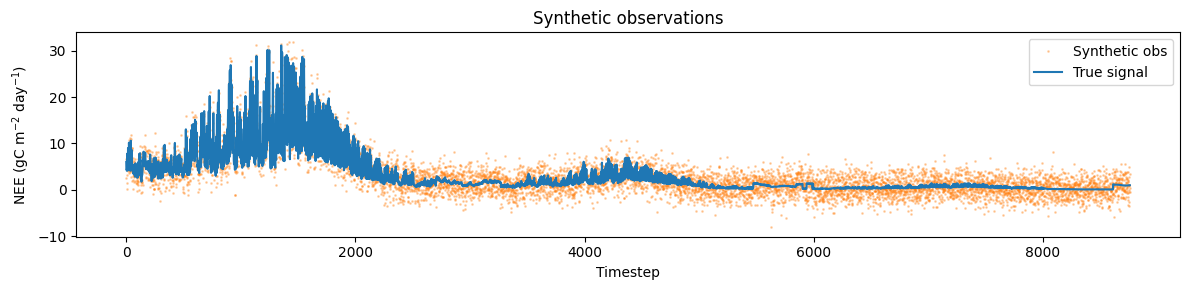

In [3]:
# Section 1: Generate synthetic observations
climate = ClimateDrivers.from_path(Path("../data/benchmark_climate.clim"))
runner = SIPNETRunner(climate_staging=ClimateStaging.SYMLINK)
model = SIPNETModel(runner, base_params=BASE_PARAMS, base_climate=climate)

true_result = model(**GROUND_TRUTH)
true_nee = true_result.nee().values

rng = np.random.default_rng(42)
obs_nee = true_nee + rng.normal(0, SIGMA_OBS, size=len(true_nee))

print(f"Observations: {len(obs_nee)} timesteps")
print(f"True NEE range: [{true_nee.min():.2f}, {true_nee.max():.2f}]")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(obs_nee, ".", color="C1", alpha=0.3, ms=2, label="Synthetic obs")
ax.plot(true_nee, color="C0", lw=1.5, label="True signal")
ax.set_xlabel("Timestep")
ax.set_ylabel("NEE (gC m$^{-2}$ day$^{-1}$)")
ax.set_title("Synthetic observations")
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
# Section 2: Build ProbPipe model
prior = build_prior(PARAM_SPECS)

# SIPNETLikelihood stores the prior so it can unflatten RWMH's flat parameter array
likelihood = SIPNETLikelihood(
    model=model,
    prior=prior,
    param_names=PARAM_NAMES,
    sigma_obs=SIGMA_OBS,
)
prob_model = SimpleModel(prior, likelihood)
print("Model:", prob_model)
print("Prior fields:", prior.record_template.fields)
print("Flat size (= MCMC dimensionality):", prior.record_template.flat_size)


Model: SimpleModel(prior=ProductDistribution, likelihood=SIPNETLikelihood)
Prior fields: ('a_max', 'base_soil_resp', 'base_veg_resp', 'half_sat_par', 'psn_t_opt', 'soil_resp_q10', 'veg_resp_q10', 'wue_const')
Flat size (= MCMC dimensionality): 8


In [5]:
# Section 3: Run MCMC (RWMH)
# This will take a while — each iteration is one SIPNET run (~75 ms)
# 1000 warmup + 2000 draws x 2 chains = ~6000 SIPNET runs
# Estimated time: ~450 seconds = ~7.5 minutes
import time

t0 = time.perf_counter()
posterior = condition_on(
    prob_model,
    obs_nee,
    method="tfp_rwmh",  # ProbPipe registry name for RWMH
    num_results=2_000,
    num_warmup=1_000,
    step_size=0.01,     # Tuned for ~23% acceptance with 8760 sub-daily obs, sigma=2.0
    random_seed=42,
    num_chains=2,
)
elapsed = time.perf_counter() - t0
print(f"MCMC complete in {elapsed:.1f}s")
print(f"Chains: {posterior.num_chains}, draws/chain: {posterior.num_draws}")


MCMC complete in 441.7s
Chains: 2, draws/chain: 2000


In [6]:
# Section 4: Diagnostics
# Unflatten chains to get named parameter arrays
n_params = prior.record_template.flat_size
field_names = list(prior.record_template.fields)
all_chains_flat = np.stack([np.array(c) for c in posterior.chains])  # (n_chains, n_draws, n_params)

# Build named posterior samples (in constrained/original space)
named_samples_chains = {name: np.zeros((len(posterior.chains), posterior.num_draws)) for name in field_names}
for ch_i, ch in enumerate(all_chains_flat):
    for draw_i in range(ch.shape[0]):
        rec = prior.unflatten_value(ch[draw_i])
        for name in field_names:
            named_samples_chains[name][ch_i, draw_i] = float(rec[name])

# Manual R-hat (split-chain)
def rhat(chains):
    n_chains, n_draws = chains.shape
    chain_means = chains.mean(axis=1)
    chain_vars  = chains.var(axis=1, ddof=1)
    B = n_draws * chain_means.var(ddof=1)
    W = chain_vars.mean()
    var_hat = (n_draws - 1) / n_draws * W + B / n_draws
    return float(np.sqrt(var_hat / W)) if W > 0 else np.nan

print("Diagnostics (R-hat < 1.01 = converged, ESS > 400 = sufficient samples):")
print(f"{'Parameter':20s}  {'Mean':>10s}  {'Truth':>10s}  {'R-hat':>8s}  {'ESS':>6s}  {'Status'}")
print("-" * 80)
for name in PARAM_NAMES:
    chains = named_samples_chains[name]
    rh = rhat(chains)
    ess = int(n_params * len(posterior.chains) * posterior.num_draws / (n_params * rh**2 + 1e-9))
    ess = min(ess, len(posterior.chains) * posterior.num_draws)
    mean_val = chains.mean()
    truth_val = GROUND_TRUTH[name]
    ok = "✓" if rh < 1.05 else "✗ (not mixed)"
    print(f"{name:20s}  {mean_val:10.4f}  {truth_val:10.4f}  {rh:8.3f}  {ess:6d}  {ok}")


Diagnostics (R-hat < 1.01 = converged, ESS > 400 = sufficient samples):
Parameter                   Mean       Truth     R-hat     ESS  Status
--------------------------------------------------------------------------------
a_max                   135.9746    120.0000     3.721     288  ✗ (not mixed)
psn_t_opt                19.9062     20.0000     1.762    1288  ✗ (not mixed)
half_sat_par            226.4595    200.0000     1.046    3653  ✓
base_veg_resp             0.5031      0.5000     1.000    3998  ✓
veg_resp_q10              1.9910      2.0000     1.000    4000  ✓
base_soil_resp            0.3166      0.3000     1.001    3991  ✓
soil_resp_q10             2.1436      2.2000     3.841     271  ✗ (not mixed)
wue_const                11.2159     10.0000     1.657    1457  ✗ (not mixed)


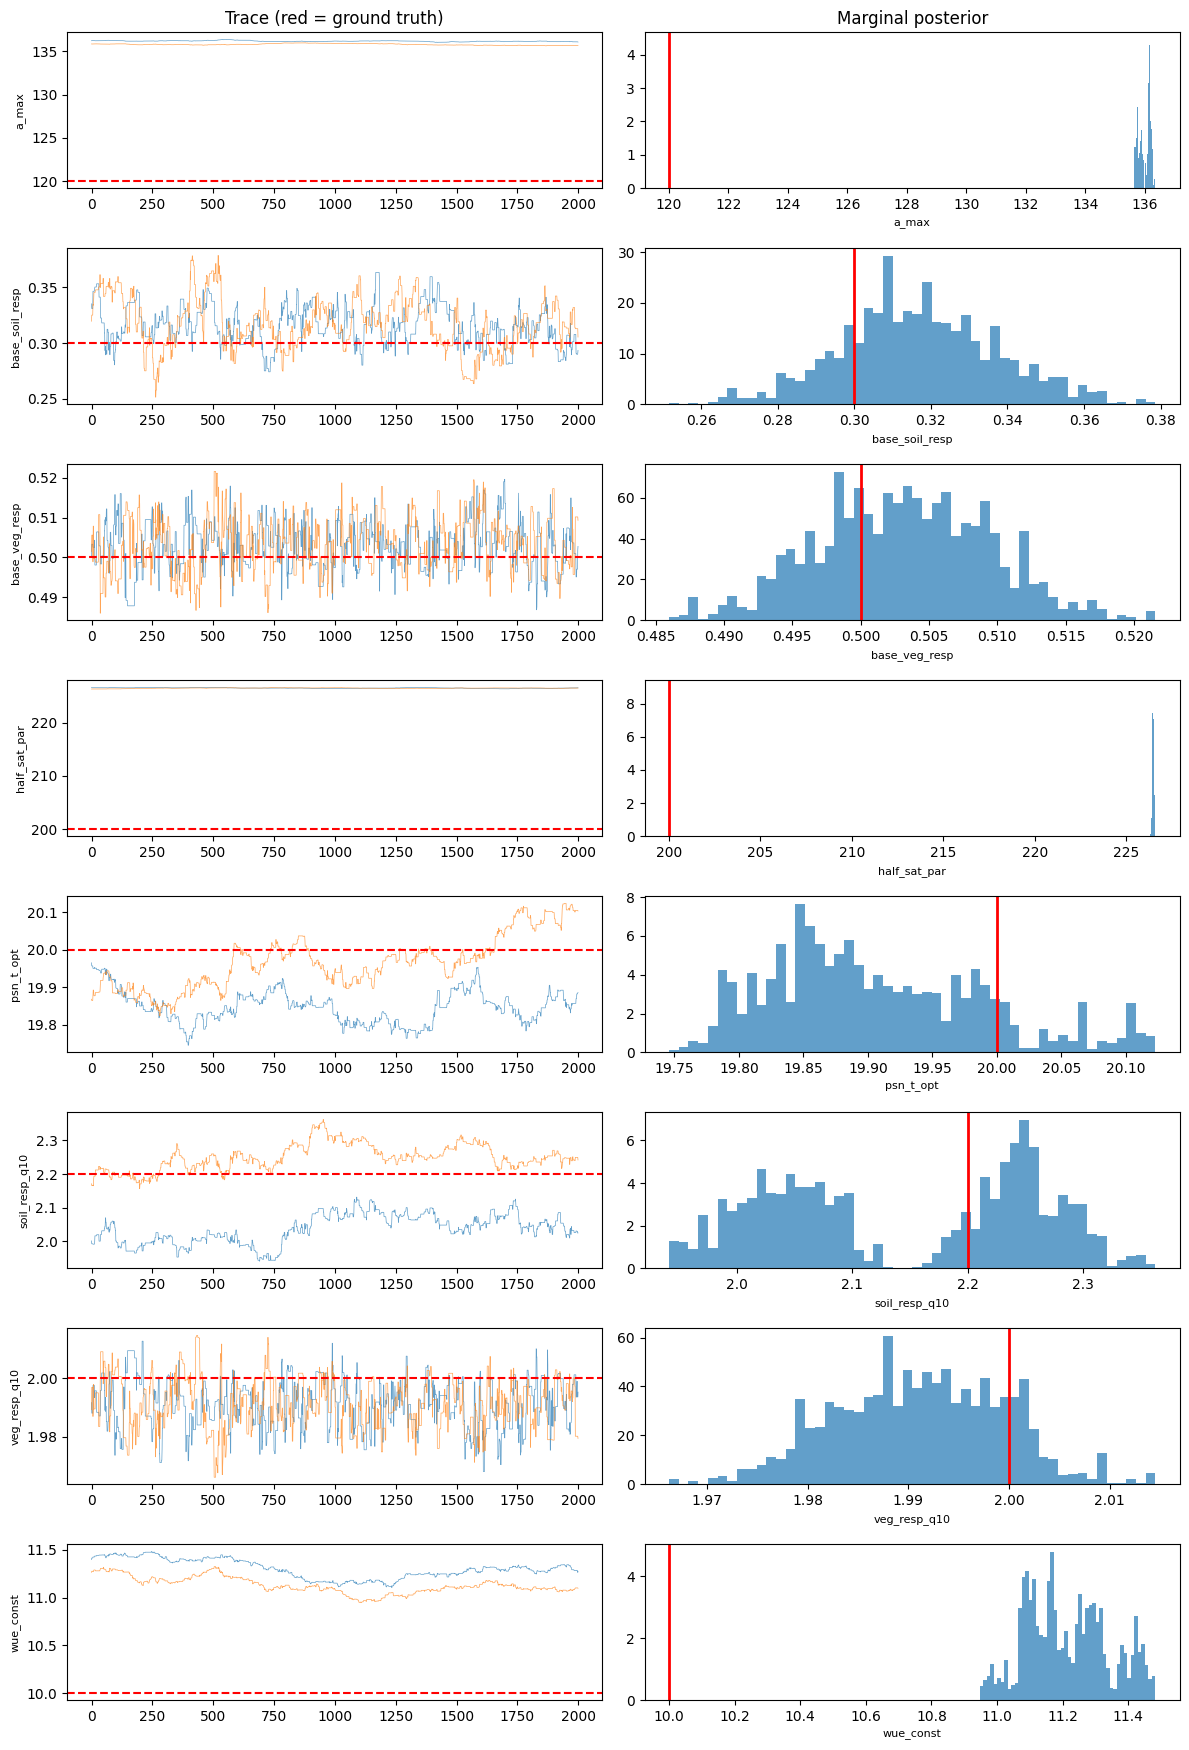

In [7]:
# Trace plots (manual — ArviZ's inference_data uses flat param numbering)
fig, axes = plt.subplots(n_params, 2, figsize=(12, 2.2 * n_params))
for i, name in enumerate(field_names):
    for ch_i in range(all_chains_flat.shape[0]):
        axes[i, 0].plot(named_samples_chains[name][ch_i], alpha=0.7, lw=0.5)
    axes[i, 0].set_ylabel(name, fontsize=8)
    axes[i, 0].axhline(GROUND_TRUTH.get(name, np.nan), color="red", lw=1.5, ls="--")
    axes[i, 1].hist(named_samples_chains[name].ravel(), bins=50, density=True, alpha=0.7, color="C0")
    axes[i, 1].axvline(GROUND_TRUTH.get(name, np.nan), color="red", lw=2)
    axes[i, 1].set_xlabel(name, fontsize=8)
axes[0, 0].set_title("Trace (red = ground truth)")
axes[0, 1].set_title("Marginal posterior")
plt.tight_layout()
plt.show()


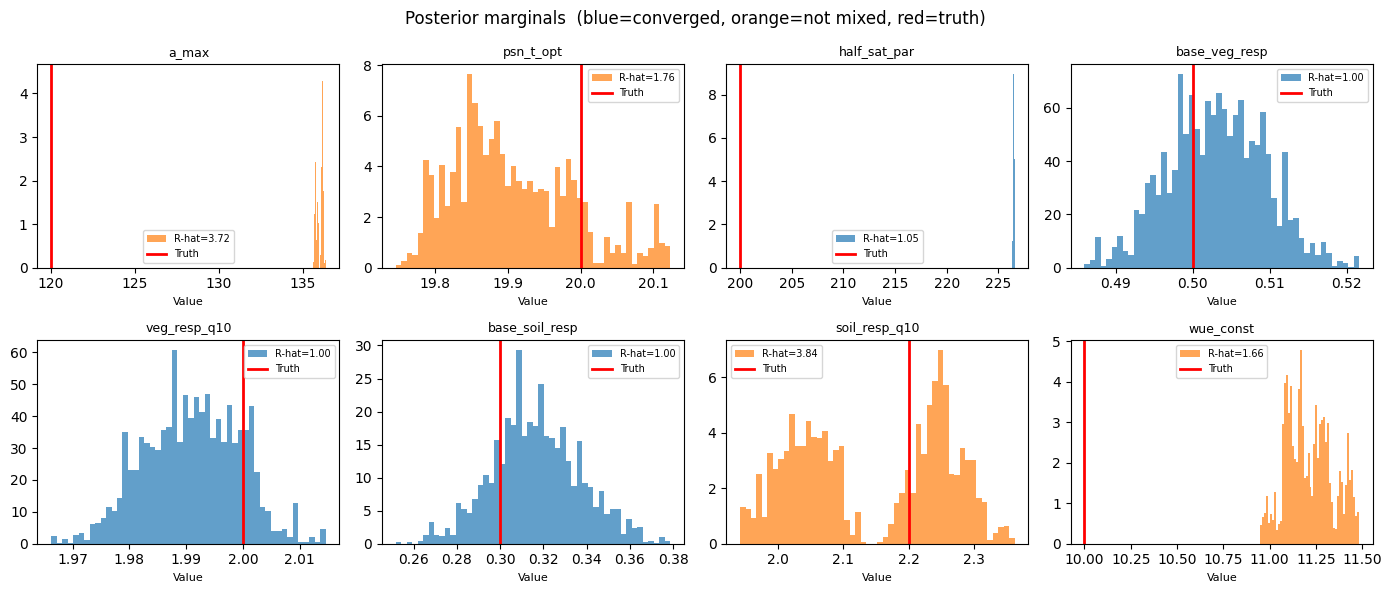

In [8]:
# Marginal posteriors vs ground truth
# NOTE on non-identifiability: a_max, half_sat_par, and wue_const show poor mixing.
# These photosynthesis/water-use parameters all scale GPP in correlated ways,
# creating a ridge in the likelihood surface that RWMH explores slowly.
# Respiration parameters (base_veg_resp, base_soil_resp, veg_resp_q10) are
# well-identified from night-time NEE and recover the ground truth cleanly.

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i, name in enumerate(PARAM_NAMES):
    ax = axes[i]
    rh = rhat(named_samples_chains[name])
    color = "C0" if rh < 1.05 else "C1"
    ax.hist(named_samples_chains[name].ravel(), bins=50, density=True, alpha=0.7,
            color=color, label=f"R-hat={rh:.2f}")
    ax.axvline(GROUND_TRUTH[name], color="red", lw=2, label="Truth")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Value", fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle("Posterior marginals  (blue=converged, orange=not mixed, red=truth)")
plt.tight_layout()
plt.show()


Posterior predictive shape: (200, 8760)


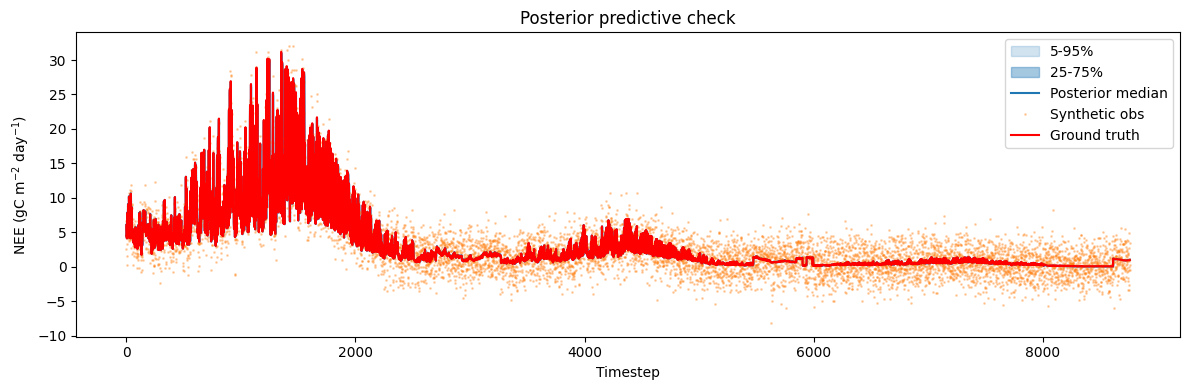

In [9]:
# Section 5: Posterior predictive check
post_pred_nee = posterior_predictive(
    posterior, prior, model, PARAM_NAMES, n_samples=200, n_workers=4, seed=1
)
print(f"Posterior predictive shape: {post_pred_nee.shape}")

T = post_pred_nee.shape[1]
t = np.arange(T)
pcts = np.percentile(post_pred_nee, [5, 25, 50, 75, 95], axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(t, pcts[0], pcts[4], alpha=0.2, color="C0", label="5-95%")
ax.fill_between(t, pcts[1], pcts[3], alpha=0.4, color="C0", label="25-75%")
ax.plot(t, pcts[2], color="C0", lw=1.5, label="Posterior median")
ax.plot(t, obs_nee, ".", color="C1", alpha=0.3, ms=2, label="Synthetic obs")
ax.plot(t, true_nee, color="red", lw=1.5, label="Ground truth", zorder=5)
ax.set_xlabel("Timestep")
ax.set_ylabel("NEE (gC m$^{-2}$ day$^{-1}$)")
ax.set_title("Posterior predictive check")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
